# Below we import packages we may need

In [ ]:
# matplotlib
import matplotlib.pyplot as plt
# pandas
import pandas as pd

Below we import the data.

In [5]:
annotated_mz_data = pd.read_csv("C:/PhD rotation 1/New Analysis Annotated mz/annotated_mz_only_post_processed_maplet_data.csv", index_col = 0)
annotated_mz_data

,341.3045359,688.1566289,480.3106071,452.2779431,137.0476093,266.1729689,275.0078481,551.3492125,343.1310698,988.5106837,...,497.2887359,522.352938,517.3715465,519.2700787,268.1195442,361.1697371,Group,Organism,date_measured,batch_measured
CARB_220421_0001,0.235379,1.255321,-0.743633,-0.451378,-0.735257,0.299373,0.487887,-0.986562,0.330911,-0.600910,...,-0.050445,-0.445337,0.862473,0.225198,0.195512,0.410076,CRE,Escherichia coli,apr21,apr21
CARB_220421_0002,0.302080,0.660567,-0.628927,0.204759,-1.734406,-0.344743,-1.674753,-0.423016,0.102218,0.417236,...,0.794827,0.220338,0.373972,0.282055,0.333397,-0.125571,CRE,Enterobacter cloacae,apr21,apr21
CARB_220421_0003,-1.162677,0.023574,-0.819531,-0.349414,-1.408124,0.422816,-0.424128,-0.797650,-1.337279,-0.055619,...,0.592715,-0.186625,1.203281,0.514182,0.197211,0.384633,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0004,-0.081062,0.785580,-2.157372,-1.714977,-1.424713,-0.197547,-0.240823,-0.608056,0.326369,0.888960,...,-0.041695,-0.431125,1.475143,0.326514,0.015376,-0.135694,CRE,Klebsiella pneumoniae,apr21,apr21
CARB_220421_0005,0.158468,1.086008,-2.315403,-1.202203,-0.033887,0.055588,1.091046,-2.002347,0.594032,0.697582,...,0.019417,-0.877367,1.926909,-0.133431,-0.162075,-0.317338,CRE,Klebsiella pneumoniae,apr21,apr21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CARB_220427_1065,-0.586130,-1.675135,0.457437,1.047182,1.004619,-0.322823,0.438064,-0.907827,0.606538,-0.640901,...,-0.132483,-0.271630,-0.609894,-0.119328,-0.169864,0.168971,CRE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1090,-1.744303,-0.207907,1.716507,1.087543,1.066645,0.438027,-0.342687,0.617194,-0.472748,-2.520532,...,0.446995,-0.484318,-0.254279,0.312930,0.264202,1.229598,CSE,Klebsiella pneumoniae,apr27,apr25_27
CARB_220427_1100,0.825350,1.079930,-0.816730,-0.876715,-1.749845,0.950413,-2.605379,0.890565,-2.061110,0.606860,...,-0.768276,-0.035163,0.302748,-0.694387,-0.524554,-0.034586,CSE,Escherichia coli,apr27,apr25_27
CARB_220427_1980,-1.438140,1.118891,0.855119,0.799500,-0.651932,-0.974634,0.048687,1.707099,0.814822,0.514977,...,0.688815,0.991651,1.294649,0.443743,0.465036,-1.296725,CRE,Escherichia coli,apr27,apr25_27


# Donut plot creation

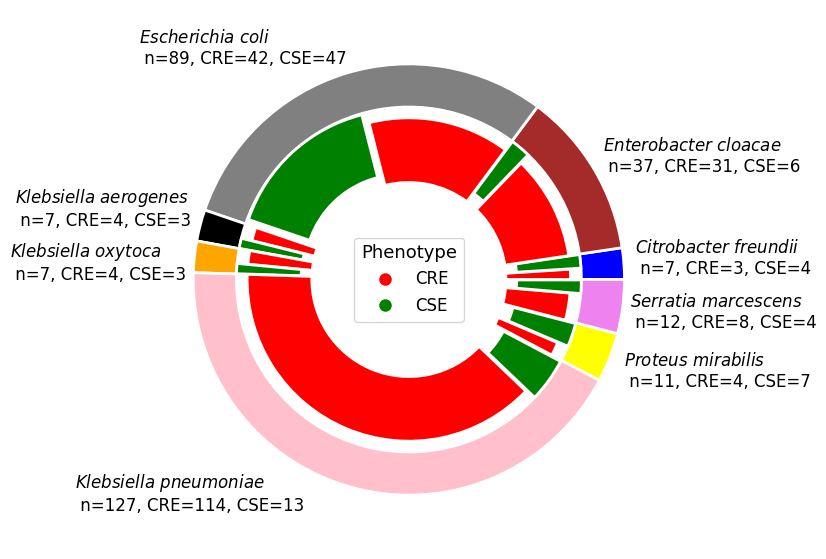

In [6]:
# Data for the outer circle (broader categories)
outer_labels = [
    r'$\it{Citrobacter\ freundii}$' + '\n n=7, CRE=3, CSE=4', 
    r'$\it{Enterobacter\ cloacae}$' + '\n n=37, CRE=31, CSE=6', 
    r'$\it{Escherichia\ coli}$' + '\n n=89, CRE=42, CSE=47', 
    r'$\it{Klebsiella\ aerogenes}$' + '\n n=7, CRE=4, CSE=3', 
    r'$\it{Klebsiella\ oxytoca}$' + '\n n=7, CRE=4, CSE=3', 
    r'$\it{Klebsiella\ pneumoniae}$' + '\n n=127, CRE=114, CSE=13', 
    r'$\it{Proteus\ mirabilis}$' + '\n n=11, CRE=4, CSE=7', 
    r'$\it{Serratia\ marcescens}$' + '\n n=12, CRE=8, CSE=4'
]
outer_sizes = [7, 37, 89, 7, 7, 127, 11, 12]  # Example sizes for outer categories

# Specify colors for the outer circle
outer_colors = ['blue', 'brown', 'gray', 'black', 'orange', 'pink', 'yellow', 'violet']

# Data for the inner circle (subcategories within each main category)
inner_labels = ['cre', 'cse', 'cre', 'cse', 'cre', 'cse', 'cre', 'cse', 
                'cre', 'cse', 'cre', 'cse', 'cre', 'cse', 'cre', 'cse']
inner_sizes = [3, 4, 31, 6, 42, 47, 4, 3, 4, 3, 114, 13, 4, 7, 8, 4]  # Example sizes for subcategories

# Specify alternating red and green colors for the inner circle
inner_colors = ['red', 'green', 'red', 'green', 'red', 'green', 'red', 'green', 
                'red', 'green', 'red', 'green', 'red', 'green', 'red', 'green']

# Explode parameter to add space between each CRE-CSE pair (alternating)
inner_explode = [0, 0.05, 0, 0.05, 0, 0.05, 0, 0.05, 0, 0.05, 0, 0.05, 0, 0.05, 0, 0.05]

# Create figure and axes
fig, ax = plt.subplots(figsize=(7, 7))

# Create the outer donut plot
ax.pie(outer_sizes, radius=1, colors=outer_colors, 
       wedgeprops=dict(width=0.2, edgecolor='w', linewidth=2), textprops={'fontsize': 12})

# Add manual labels with bbox and transform adjustments
label_positions = [(0.92, 0.51), (0.86, 0.7), (0, 0.9), (-0.23, 0.6), 
                  (-0.24, 0.5), (-0.12, 0.07), (0.9, 0.3), (0.91, 0.41)]  # x, y positions for labels

for i, label in enumerate(outer_labels):
    # Place each label at the specified position using bbox
    ax.text(label_positions[i][0], label_positions[i][1], label,
            bbox=dict(facecolor='white', edgecolor='white', boxstyle='round,pad=0.1'),
            fontsize=12, transform=ax.transAxes)  # Using transform=ax.transAxes for axis coordinates

# Create the inner donut plot with selective explode for whitespace after every CRE-CSE pair
ax.pie(inner_sizes, radius=0.75, colors=inner_colors, explode=inner_explode, 
       wedgeprops=dict(width=0.3, edgecolor='w', linewidth=2), textprops={'fontsize': 12})

# Add a central circle to make it look like a donut
centre_circle = plt.Circle((0, 0), 0.3, color='white', fc='white', linewidth=1.25)
fig.gca().add_artist(centre_circle)

# Create custom legend handles
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
                  for label, color in zip(['CRE', 'CSE'], ['red', 'green'])]

# Add legend inside the plot
plt.legend(handles=legend_handles, title="Phenotype", loc="center", bbox_to_anchor=(0.5, 0.5), fontsize=12, title_fontsize='13')

# Equal aspect ratio ensures that pie is drawn as a circle
ax.set(aspect="equal")

# Save fig
plt.savefig("C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/donut_plot_sample_visualization.png", bbox_inches = 'tight')
plt.savefig('C:/PhD rotation 1/New Analysis Annotated mz/Final Figures/donut_plot_sample_visualization.tiff', format='tiff', dpi=300, bbox_inches="tight")

# Display the plot
plt.show()
